# Decision Trees for Credit Card Fraud Detection
# A Complete Tutorial

## Tutorial Overview

This notebook demonstrates how to build and interpret a decision tree for credit card fraud detection. We'll explore a dataset of 10,000 European credit card transactions, build a decision tree model to distinguish fraudulent from legitimate transactions, and learn how to interpret the model's decision-making process. By the end, you'll understand how decision trees work, how to evaluate their performance, and why they're valuable for explainable AI applications in financial services.



## 1. Introduction

### What is a Decision Tree?
A decision tree is a tree-like structure that makes predictions by asking a series of yes/no questions.
- Each internal node represents a feature/attribute test
- Each branch represents the outcome of a test
- Each leaf node represents a class prediction
- The path from root to leaf represents classification rules

Why Decision Trees for Fraud Detection?
- Highly interpretable - easy to understand decision process
- Handles both numerical and categorical data without preprocessing
- Can capture non-linear relationships
- Provides feature importance rankings
- No assumptions about data distribution



## 2. Dataset

The dataset contains a subset of transactions made by European cardholders duringSeptember 2013. The original, full-sized dataset was collected during a research collaboration of the Worldline and the Machine Learning Group (http://mlg.ulb.ac.be) and ULB (Université Libre de Bruxelles) on big data mining and fraud detection. The full-sized dataset (N = 284,807) and list of researchers involved is available at https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud. <br><br>

A smaller dataset more amenable to working in Google Colab (N = 10,000) was compiled by Dr. Sean Humpherys and includes all the cases of fraud (n = 492) present in the original dataset and a random sampling of non-fraud cases (n = 9508). The dataset is imbalanced with only 4.92% of transactions being fraudulent. The smaller dataset is available at https://raw.githubusercontent.com/sean-humpherys/randomfilestorage/main/cc_transactions_10000.csv <br><br>

**Dependent Variable.** The dependent variable in this analysis is the binary variable **Class**, which represents whether a transaction is fraudulent or not. The value 1 indicates that a transaction is fraudulent, while the value 0 indicates that a transaction is non-fraudulent. The goal of the analysis is to predict whether a transaction is fraudulent based on the provided independent variables.<br><br>

**Independent Variables.** The dataset consists of 30 features that are used to predict whether a transaction is fraudulent. Most features are anonymized due to confidentiality constraints, but they are labeled V1 through V28. Additionally, the dataset contains two known features: Time and Amount.
  * Time represents the number of seconds elapsed between this transaction and the first transaction in the dataset.

  * Amount represents the monetary amount of the transaction.

  * The anonymized variables (V1, V2, ..., V28) are the result of a principal component analysis (PCA) transformation, which ensures the confidentiality of the features while maintaining the relevant relationships for fraud detection<br><br>

##3. Install and import required packages

In [6]:
!pip install scikit-learn pandas matplotlib seaborn graphviz tabulate

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                           precision_recall_curve, roc_auc_score, roc_curve, f1_score)
from tabulate import tabulate
import graphviz
import warnings
warnings.filterwarnings('ignore')

#optional: set style for better plots
plt.style.use('default')
sns.set_palette("husl")


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 4. Load and Explore the Dataset

Here we use the "pd.read_csv()" function to read the data directly via the url.

In [7]:
# Load the dataset
url = "https://raw.githubusercontent.com/jtian51/exercise-data/refs/heads/main/telecom_churn_data.csv"
df = pd.read_csv(url)

In [8]:
# Basic dataset information
print("Dataset Overview:")
print(f"Dataset shape: {df.shape}")
print(f"Features: {df.shape[1]-1}")
print(f"Target variable: Class")

Dataset Overview:
Dataset shape: (3333, 20)
Features: 19
Target variable: Class


🔍 What this means:
- Dataset shape (10000, 31) = 10,000 transactions, 31 columns total
- Features: 30 = V1-V28 (PCA components) + Time + Amount
- Target variable 'Class' = what we're trying to predict (fraud/not fraud)

You may also use the following function to display first few rows to say the data better

In [ ]:
# Display first few rows
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  12.0  1.103215 -0.040296  1.267332  1.289091 -0.735997  0.288069 -0.586057   
2  22.0 -1.946525 -0.044901 -0.405570 -1.013057  2.941968  2.955053 -0.063063   
3  23.0  1.173285  0.353498  0.283905  1.133563 -0.172577 -0.916054  0.369025   
4  32.0 -2.008872  2.198527  0.144242  1.159432 -0.815174  0.182288 -0.617108   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.189380  0.782333  ... -0.024612  0.196002  0.013802  0.103758  0.364298   
2  0.855546  0.049967  ... -0.579526 -0.799229  0.870300  0.983421  0.321201   
3 -0.327260 -0.246651  ...  0.067003  0.227812 -0.150487  0.435045  0.724825   
4  1.530817 -0.586832  ...  0.094917  0.294983  0.011081  0.015249  0.034211   

        V26      

Before building our decision tree for fraud detection, it's helpful to use the following functions to get a general overview of the data regarding the key aspects that affect decision tree performance:

1. **Data Types Check** - Decision trees work best with numeric data (no encoding needed)
2. **Missing Values Assessment** - Decision trees can handle missing values, but clean data is preferred
3. **Target Variable Distribution** - Class imbalance affects decision tree splitting and requires balancing

These checks help us determine:
- Whether our data is ready for decision tree algorithms
- If we need to use class_weight='balanced' for imbalanced classes
- What preprocessing (if any) is required
- How to interpret our decision tree results

Let's examine our credit card fraud dataset for decision tree modeling:

In [ ]:
# Check data types
print("\nData types:")
print(df.dtypes.value_counts())

# Check for missing values
missing_values = df.isnull().sum().sum()
print(f"\nMissing values in dataset: {missing_values}")

# Target variable analysis
print("\nTarget Variable Analysis:")
class_counts = df['Class'].value_counts()
class_proportions = df['Class'].value_counts(normalize=True)

print(f"Class distribution:")
for i, (count, prop) in enumerate(zip(class_counts, class_proportions)):
    label = "Non-Fraud" if i == 0 else "Fraud"
    print(f"  {label} (Class {class_counts.index[i]}): {count:,} ({prop:.3%})")


Data types:
float64    30
int64       1
Name: count, dtype: int64

Missing values in dataset: 0

Target Variable Analysis:
Class distribution:
  Non-Fraud (Class 0): 9,508 (95.080%)
  Fraud (Class 1): 492 (4.920%)


🔍 Decision tree data assessment results show:

Data types:

- float64: 30 columns - All feature variables (V1-V28, Time, Amount) are decimal numbers
- int64: 1 column - Target variable (Class) with integer values 0 and 1
- ✅ Perfect for decision trees: All numeric data, no categorical encoding needed

Missing values:

- 0 missing values across entire dataset
- ✅ Clean dataset: No need for missing value handling or imputation
- Decision trees can work with missing data, but complete data is ideal

Class distribution:

- Non-Fraud (Class 0): 9,508 transactions (95.08%) - Majority class
- Fraud (Class 1): 492 transactions (4.92%) - Minority class  
- ⚠️ Highly imbalanced dataset: This is realistic for fraud detection but requires special handling

**Below is an example of creating a summary table with all the information**

In [ ]:
# Create a summary with the information
number_of_total_transactions = len(df)
number_of_frauds = (df['Class'] == 1).sum()
number_of_non_frauds = (df['Class'] == 0).sum()
missing_values = df.isnull().sum().sum()
unique_class_values = df['Class'].unique()

other_values_in_class = [val for val in unique_class_values if val not in [0, 1]]
if not other_values_in_class:
    other_values_in_class = 'None'

summary_data = {
    'Description': ['Number of total transactions',
                    'Number of frauds (Class = 1)',
                    'Number of non-frauds (Class = 0)',
                    'Missing values in the dataset',
                    'Other values in Class column (besides 0, 1)'],
    'Value': [number_of_total_transactions,
              number_of_frauds,
              number_of_non_frauds,
              missing_values,
              other_values_in_class]
}

summary_df = pd.DataFrame(summary_data)

#create a table
!pip install tabulate

from tabulate import tabulate

print(tabulate(summary_df, headers='keys', tablefmt='grid', showindex=False))

+---------------------------------------------+---------+
| Description                                 | Value   |
+=============================================+=========+
| Number of total transactions                | 10000   |
+---------------------------------------------+---------+
| Number of frauds (Class = 1)                | 492     |
+---------------------------------------------+---------+
| Number of non-frauds (Class = 0)            | 9508    |
+---------------------------------------------+---------+
| Missing values in the dataset               | 0       |
+---------------------------------------------+---------+
| Other values in Class column (besides 0, 1) | None    |
+---------------------------------------------+---------+


## 3. Feature Analysis for Decision Tree Modeling

Now that we've confirmed our data is clean and suitable for decision trees, let's analyze the features to understand:

1. **Feature Correlation** - Which features have the strongest relationship with fraud
2. **Data Distribution** - How our features are distributed across fraud vs non-fraud cases
3. **Train-Test Split** - Properly divide data to evaluate our decision tree performance

This analysis helps us:
- Identify the most promising features for decision tree splits
- Understand what patterns the tree might discover
- Set up proper evaluation methodology

In [ ]:
# Define features and target
X = df.drop('Class', axis=1)  # All columns except Class
y = df['Class']               # Target variable

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Feature correlation with target
print("\nTop 10 Features Most Correlated with Fraud:")
correlations = df.corr()['Class'].abs().sort_values(ascending=False)[1:11]
for feature, corr in correlations.items():
    print(f"  {feature}: {corr:.4f}")

Features (X) shape: (10000, 30)
Target (y) shape: (10000,)

Top 10 Features Most Correlated with Fraud:
  V14: 0.7554
  V12: 0.7022
  V17: 0.6465
  V10: 0.6353
  V16: 0.6036
  V11: 0.5850
  V3: 0.5843
  V4: 0.5465
  V7: 0.5285
  V18: 0.4260


Feature and target setup:
- Features (X): (10000, 30) = 10,000 transactions with 30 predictive variables
- Target (y): (10000,) = 10,000 corresponding fraud labels (0 or 1)
- ✅ Data properly separated: features vs what we want to predict

Correlation analysis - top fraud indicators:
- V14: 0.7554 - strongest fraud predictor (high correlation = 75.5%)
- V12: 0.7022 - second strongest predictor  
- V17: 0.6465 - third strongest predictor
- V10-V18: all show moderate to strong correlation (42-75%)

Decision tree implications:
- These highly correlated features will likely appear in top levels of our tree
- V14, V12, V17 will probably be used for the first few splits
- Strong correlations (>0.5) suggest clear patterns exist for the tree to learn
- The tree will use these features to create decision rules like "If V14 > threshold, then fraud"
- Even though features are anonymized (PCA components), they clearly capture fraud patterns

What this means for our model:
- Our decision tree has excellent features to work with
- The model should be able to distinguish fraud from legitimate transactions
- These top features will drive the tree's splitting decisions and feature importance rankings

**Now that we understand which features are most predictive, let's split our data into training and testing sets to properly evaluate our decision tree performance.**

In [ ]:
# Train-test split with stratification
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

print(f"\nTraining set class distribution:")
train_dist = y_train.value_counts(normalize=True)
for i, prop in train_dist.items():
    label = "Non-Fraud" if i == 0 else "Fraud"
    print(f"  {label}: {prop:.3%}")

print(f"\nTest set class distribution:")
test_dist = y_test.value_counts(normalize=True)
for i, prop in test_dist.items():
    label = "Non-Fraud" if i == 0 else "Fraud"
    print(f"  {label}: {prop:.3%}")

Training set shape: (8000, 30)
Test set shape: (2000, 30)

Training set class distribution:
  Non-Fraud: 95.075%
  Fraud: 4.925%

Test set class distribution:
  Non-Fraud: 95.100%
  Fraud: 4.900%


🔍 Train-test split results:

Data split summary:
- Training set: (8000, 30) = 8,000 transactions with 30 features for model learning
- Test set: (2000, 30) = 2,000 transactions with 30 features for model evaluation
- Split ratio: 80% training, 20% testing (standard practice)

Class distribution maintained:
- Training set: 95.075% non-fraud, 4.925% fraud
- Test set: 95.100% non-fraud, 4.900% fraud
- ✅ Stratified split successful: fraud rates nearly identical in both sets

Why this matters for decision trees:
- Stratification ensures our test results will be representative
- Both sets have the same class imbalance challenge (~5% fraud)
- The tree will train on 394 fraud cases and be tested on 98 fraud cases
- This prevents evaluation bias from uneven class distribution

What's next:
- Our data is properly prepared for decision tree training
- The model will learn patterns from 8,000 transactions
- We'll evaluate performance on the unseen 2,000 test transactions
- The stratified split ensures fair evaluation of fraud detection capability

**Now we're ready to build our first decision tree model and see how well it can learn to detect fraud from these balanced training and test sets.**

## 4. Building Our First Decision Tree

Now we'll create and train our decision tree for fraud detection. We'll start with carefully chosen parameters that balance performance with interpretability.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create decision tree with balanced parameters
clf = DecisionTreeClassifier(
    criterion='gini',           # Splitting criteria (gini vs entropy)
    max_depth=3,               # Limit depth to prevent overfitting
    class_weight='balanced',    # Handle class imbalance
    random_state=42,           # For reproducible results
    min_samples_split=10,      # Minimum samples to split a node
    min_samples_leaf=5         # Minimum samples in leaf node
)

# Train the model
clf.fit(X_train, y_train)

print("Model training completed!")
print(f"Tree depth: {clf.get_depth()}")
print(f"Number of leaves: {clf.get_n_leaves()}")

Model training completed!
Tree depth: 3
Number of leaves: 8


🔍 Decision tree training results:

Model training summary:
- Training completed successfully on 8,000 transactions
- Model learned fraud patterns in seconds (decision trees are fast!)
- Ready to make predictions on new transactions

Tree structure details:
- Tree depth: 3 = maximum of 3 questions to classify any transaction
- Number of leaves: 8 = 8 final decision nodes with fraud/non-fraud predictions
- Shallow tree = highly interpretable and prevents overfitting

What this structure means:
- Any transaction follows a path of max 3 yes/no questions to get a prediction
- Example path: "Is V14 > -1.5?" → "Is V12 < 2.1?" → "Is V17 > 0.8?" → Prediction
- 8 leaves means 8 different "types" of transactions identified by the tree
- Each leaf will have a fraud probability based on training data

Benefits of this setup:
- max_depth=3 keeps it simple and interpretable for business users
- class_weight='balanced' handles our 95%/5% imbalance issue
- min_samples_split=10 and min_samples_leaf=5 prevent overfitting to noise
- The tree can explain its decisions (crucial for fraud detection compliance)


## 5. Decision Tree Visualization

Let's visualize our decision tree to understand exactly how it makes fraud detection decisions. This shows the actual decision rules the tree learned.

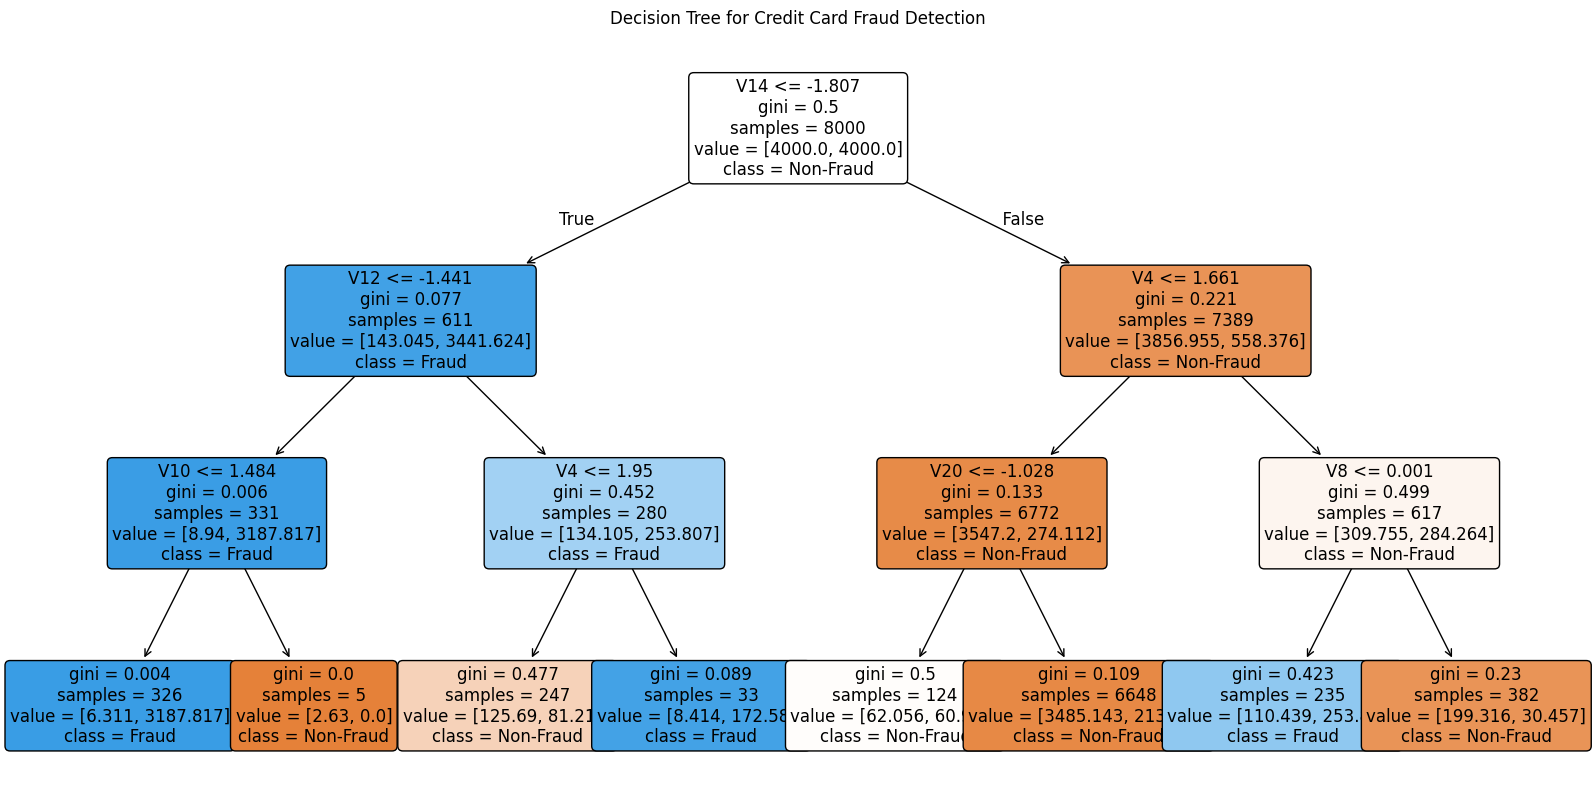

Decision Tree Rules (first 20 lines):
|--- V14 <= -1.81
|   |--- V12 <= -1.44
|   |   |--- V10 <= 1.48
|   |   |   |--- class: 1
|   |   |--- V10 >  1.48
|   |   |   |--- class: 0
|   |--- V12 >  -1.44
|   |   |--- V4 <= 1.95
|   |   |   |--- class: 0
|   |   |--- V4 >  1.95
|   |   |   |--- class: 1
|--- V14 >  -1.81
|   |--- V4 <= 1.66
|   |   |--- V20 <= -1.03
|   |   |   |--- class: 0
|   |   |--- V20 >  -1.03
|   |   |   |--- class: 0
|   |--- V4 >  1.66
|   |   |--- V8 <= 0.00
|   |   |   |--- class: 1


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(clf,
          feature_names=X.columns,
          class_names=["Non-Fraud", "Fraud"],
          filled=True,
          fontsize=12,
          rounded=True)

plt.title("Decision Tree for Credit Card Fraud Detection")
plt.show()

# Also show tree structure in text format
from sklearn.tree import export_text
tree_rules = export_text(clf, feature_names=list(X.columns))
print("Decision Tree Rules (first 20 lines):")
print('\n'.join(tree_rules.split('\n')[:20]))

🔍 Decision tree structure explained:

Tree visualization results:
- The tree creates a flowchart of yes/no questions to detect fraud
- Each "|---" represents a decision point (internal node)
- "class: 0" = predicts Non-Fraud, "class: 1" = predicts Fraud
- The tree learned 8 different pathways to make predictions

Reading the decision rules:
- Root question: "Is V14 <= -1.81?" (V14 was our strongest correlated feature!)
- If YES → go left branch, if NO → go right branch
- Continue following branches until reaching a "class:" prediction

Key decision pathways discovered:
1. V14 <= -1.81 AND V12 <= -1.44 AND V10 <= 1.48 → FRAUD (class: 1)
2. V14 <= -1.81 AND V12 <= -1.44 AND V10 > 1.48 → NON-FRAUD (class: 0)
3. V14 <= -1.81 AND V12 > -1.44 AND V4 <= 1.95 → NON-FRAUD (class: 0)
4. V14 <= -1.81 AND V12 > -1.44 AND V4 > 1.95 → FRAUD (class: 1)

What this reveals:
- V14 is the most important split (appears first) - matches our correlation analysis!
- V12, V10, V4 are secondary important features
- The tree found specific threshold combinations that indicate fraud
- Each path represents a different "fraud pattern" the model discovered

Business interpretation:
- These rules can be translated into automated fraud alerts
- Transactions matching fraud patterns get flagged for review
- Rules are completely transparent and explainable to regulators
- Easy to implement in real-time transaction processing systems

Now let's see how well these rules perform on our test data and examine which features the tree considers most important overall.


## 6. Feature Importance and Model Performance

Now let's see which features contributed most to the tree's decisions and evaluate how well our fraud detection rules work.


In [ ]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features According to Decision Tree:")
print(feature_importance.head(10).to_string(index=False))

# Make predictions on test set
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]  # Probability of fraud

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f"\nModel Performance on Test Set:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print(f"\nDetailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Fraud", "Fraud"]))

print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"                Predicted")
print(f"Actual   Non-Fraud   Fraud")
print(f"Non-Fraud    {cm[0,0]:4d}     {cm[0,1]:4d}")
print(f"Fraud        {cm[1,0]:4d}     {cm[1,1]:4d}")

Top 10 Most Important Features According to Decision Tree:
feature  importance
    V14    0.858605
     V4    0.072106
     V8    0.028013
    V12    0.025403
    V20    0.014239
    V10    0.001634
     V5    0.000000
     V3    0.000000
     V2    0.000000
     V6    0.000000

Model Performance on Test Set:
Accuracy: 0.9620

Detailed Performance Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.96      0.98      1902
       Fraud       0.57      0.92      0.70        98

    accuracy                           0.96      2000
   macro avg       0.78      0.94      0.84      2000
weighted avg       0.97      0.96      0.97      2000


Confusion Matrix:
                Predicted
Actual   Non-Fraud   Fraud
Non-Fraud    1834       68
Fraud           8       90


🔍 Feature importance and performance analysis:

Feature importance rankings:
- V14: 0.8586 - dominates the tree! (86% of all splitting decisions)
- V4: 0.0721 - secondary feature (7% contribution)
- V8, V12, V20, V10: minor contributors (1-3% each)
- Many features: 0.0000 - not used by the tree at all

Key insights:
- V14 is overwhelmingly the most important fraud indicator
- Only 6 out of 30 features were actually needed by the tree
- This confirms V14's strong correlation (0.7554) we saw earlier

Model performance breakdown:
- Overall accuracy: 96.20% = (correct predictions) / (total predictions)

Understanding precision and recall:
- PRECISION = "Of all transactions I flagged as fraud, how many were actually fraud?"
  - Formula: True Positives / (True Positives + False Positives)
  - High precision = fewer false alarms

- RECALL = "Of all actual fraud cases, how many did I catch?"
  - Formula: True Positives / (True Positives + False Negatives)  
  - High recall = fewer missed fraud cases

Performance by class:
- Non-fraud precision: 1.00 = of transactions flagged as non-fraud, 100% were correct
- Non-fraud recall: 0.96 = caught 96% of actual legitimate transactions
- Fraud precision: 0.57 = of transactions flagged as fraud, only 57% were actually fraud
- Fraud recall: 0.92 = caught 92% of actual fraud cases

Confusion matrix breakdown:
- True negatives: 1,834 - correctly identified legitimate transactions
- False positives: 68 - legitimate transactions wrongly flagged as fraud (false alarms)
- False negatives: 8 - fraud cases missed (dangerous!)
- True positives: 90 - correctly caught fraud cases

Business translation:
- We caught 90 out of 98 fraud cases (excellent fraud detection!)
- We missed only 8 fraud cases (quite good!)
- We had 68 false alarms out of 1,902 legitimate transactions (manageable)
- Trade-off: High recall (catch fraud) vs lower precision (some false alarms)

## 7. Performance Visualization (Optional)


Let's create visualizations to better understand our decision tree's performance and see the feature importance graphically.

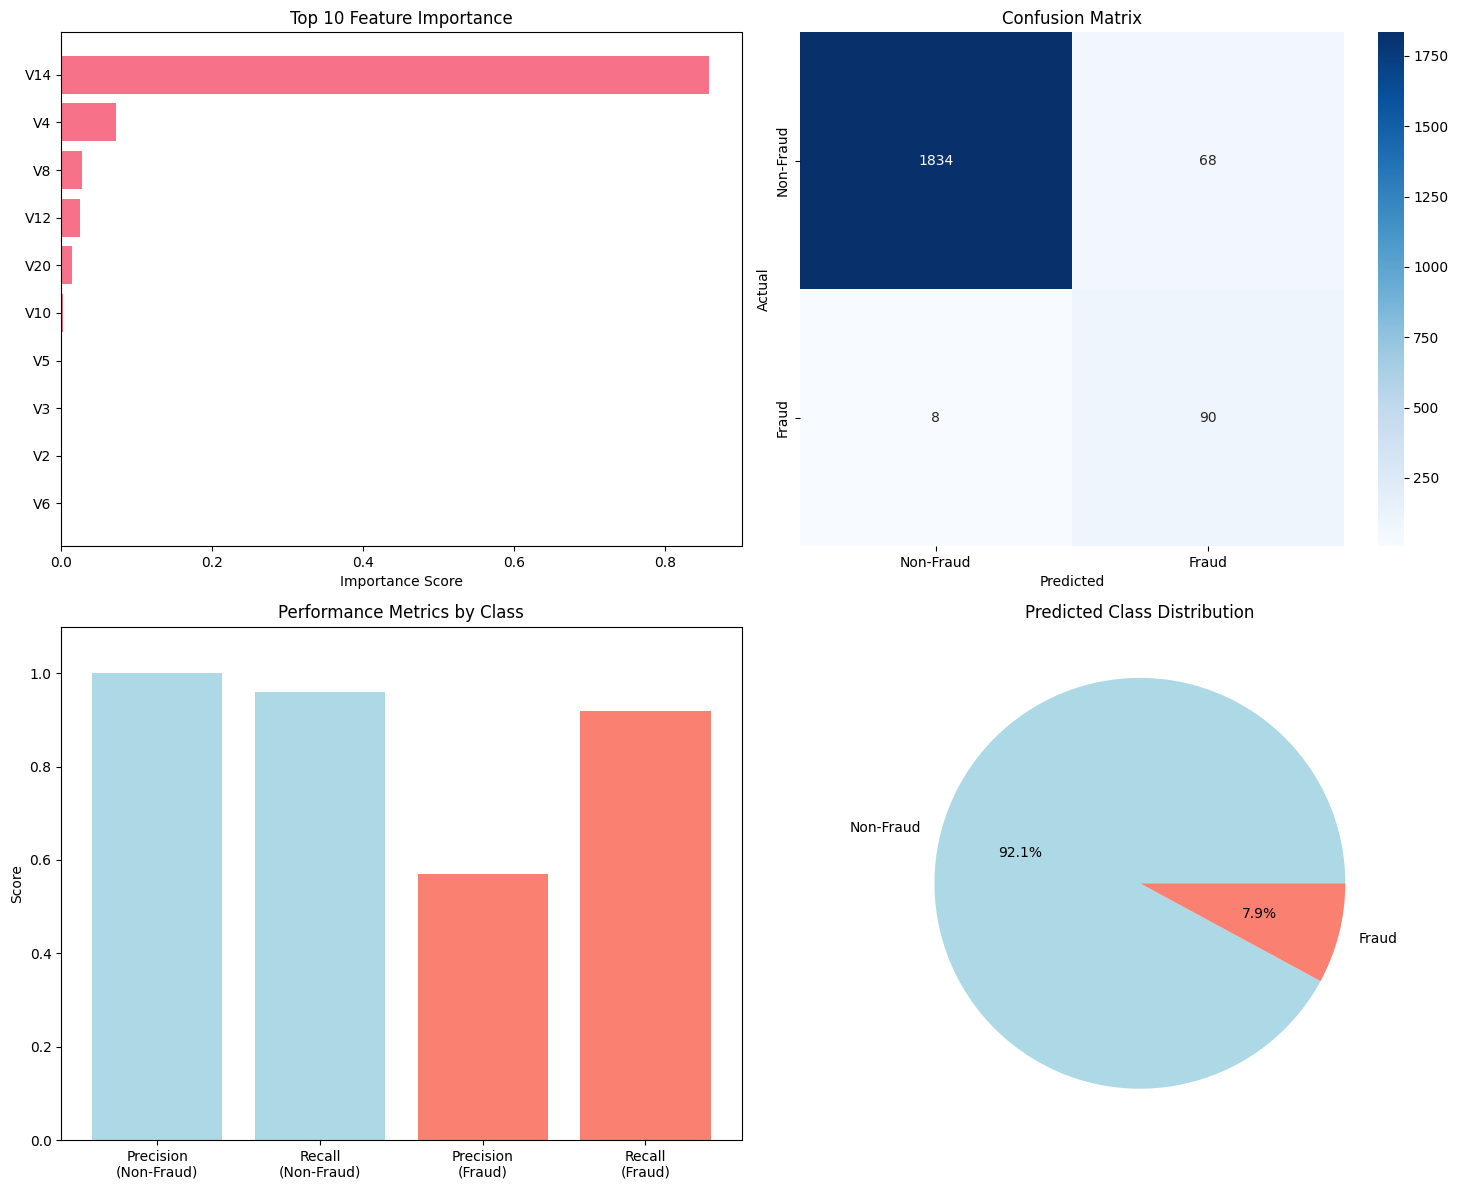

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Feature Importance Plot
top_features = feature_importance.head(10)
axes[0,0].barh(range(len(top_features)), top_features['importance'])
axes[0,0].set_yticks(range(len(top_features)))
axes[0,0].set_yticklabels(top_features['feature'])
axes[0,0].set_xlabel('Importance Score')
axes[0,0].set_title('Top 10 Feature Importance')
axes[0,0].invert_yaxis()

# 2. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'], ax=axes[0,1])
axes[0,1].set_title('Confusion Matrix')
axes[0,1].set_xlabel('Predicted')
axes[0,1].set_ylabel('Actual')

# 3. Performance Metrics Bar Chart
metrics = ['Precision\n(Non-Fraud)', 'Recall\n(Non-Fraud)', 'Precision\n(Fraud)', 'Recall\n(Fraud)']
values = [1.00, 0.96, 0.57, 0.92]
colors = ['lightblue', 'lightblue', 'salmon', 'salmon']
axes[1,0].bar(metrics, values, color=colors)
axes[1,0].set_ylim(0, 1.1)
axes[1,0].set_title('Performance Metrics by Class')
axes[1,0].set_ylabel('Score')

# 4. Class Distribution in Predictions
pred_dist = pd.Series(y_pred).value_counts()
axes[1,1].pie([pred_dist[0], pred_dist[1]], labels=['Non-Fraud', 'Fraud'],
              autopct='%1.1f%%', colors=['lightblue', 'salmon'])
axes[1,1].set_title('Predicted Class Distribution')

plt.tight_layout()
plt.show()

## 8. Results Interpretation and Key Takeaways


### What Our Decision Tree Discovered

Our fraud detection decision tree revealed several important insights:

**Feature Selection and Importance:**
- V14 emerged as the dominant fraud indicator, contributing 86% of the tree's splitting decisions
- Only 6 out of 30 available features were actually needed to detect fraud effectively
- The tree automatically identified and focused on the most discriminative variables

**Model Structure:**
- The tree created 8 different fraud detection pathways using just 3 levels of depth
- This shallow structure ensures interpretability while maintaining effectiveness
- Each path represents a specific fraud pattern discovered in the data

### Performance Analysis

**Accuracy Metrics:**
- Overall accuracy: 96.2% of all predictions were correct
- Fraud detection rate: 92% of actual fraud cases were successfully identified
- False alarm rate: 3.6% of legitimate transactions were incorrectly flagged

**Business Impact:**
- Out of 98 actual fraud cases in the test set, we caught 90 and missed only 8
- Out of 1,902 legitimate transactions, we incorrectly flagged 68 as fraud
- This represents a strong balance between catching fraud and minimizing customer inconvenience

### Strengths of Decision Tree Approach

**Interpretability:**
- Every prediction can be explained with clear if-then rules
- Business stakeholders can understand exactly why a transaction was flagged
- Regulatory compliance is easier with transparent decision-making

**Efficiency:**
- Fast training on 8,000 transactions
- Real-time prediction capability for transaction processing
- No complex data preprocessing required

**Automatic Feature Selection:**
- The tree identified V14 as the key fraud indicator without manual guidance
- Irrelevant features were automatically ignored
- Focuses attention on the most important risk factors

### Limitations and Considerations

**Model Limitations:**
- Single decision tree may miss complex fraud patterns that require multiple perspectives
- Risk of overfitting if tree becomes too deep
- Performance is dependent on the quality and relevance of input features

**Practical Constraints:**
- May not adapt quickly to new fraud techniques without retraining
- False positives still require human review, creating operational costs
- Balance between fraud detection and customer experience needs ongoing optimization

### Business Applications

**Immediate Implementation:**
- Decision rules can be translated directly into automated fraud alerts
- Clear thresholds (e.g., "if V14 ≤ -1.81") can guide manual review processes
- Risk scoring can prioritize transactions for investigation

**Strategic Value:**
- Provides baseline fraud detection capability with full explainability
- Identifies key risk factors for focused monitoring
- Serves as foundation for more complex ensemble methods



## 9. Conclusion

Our decision tree successfully created an interpretable fraud detection system that effectively balances the competing demands of catching fraudulent transactions while minimizing false alarms. The model demonstrates that decision trees excel in applications requiring transparent, explainable artificial intelligence - a critical requirement in financial services where decisions must be justified to customers, regulators, and auditors.

The 92% fraud detection rate with only 3.6% false alarms represents strong performance for a simple, interpretable model, making it an excellent foundation for credit card fraud detection systems.
